In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import torch
import json
import os
from torch_geometric.nn import global_mean_pool
import src.global_config as global_cfg
import src.stats.config as cfg
import src.gnn.config as ecfg
import src.gnn.model as sage
import src.gnn.data_loader as gnnDataLoader
import src.gnn.train as train
import src.gnn.pipeline as pipeline
import src.gnn.analysis as eanalysis
import src.gnn.visualization as eviz
import src.stats.analysis as stat_analysis
import src.stats.visualization as stat_viz

In [25]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)
feature_mode = ecfg.FEATURE_MODE
snapshot_2003 = gnnDataLoader.json_to_pyg_data(raw_json, feature_mode=feature_mode)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 1], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 1


In [26]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cpu


In [27]:


model = sage.GraphSAGEEncoder(ecfg.IN_CHANNELS, ecfg.HIDDEN_CHANNELS, ecfg.OUT_CHANNELS, ecfg.DROPOUT_RATE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ecfg.LR_INITIAL, weight_decay=ecfg.WEIGHT_DECAY)
criterion = torch.nn.BCEWithLogitsLoss()

In [28]:
trained_model = train.train_linkpred(model, data, optimizer,  criterion, device, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.7352
Epoch 020 | Loss: 0.4308
Epoch 040 | Loss: 0.3919
Epoch 060 | Loss: 0.3850
Epoch 080 | Loss: 0.3750
Epoch 100 | Loss: 0.3710
Epoch 120 | Loss: 0.3636
Epoch 140 | Loss: 0.3762
Epoch 160 | Loss: 0.3662
Epoch 180 | Loss: 0.3725
Epoch 200 | Loss: 0.3710
dimension de embeddings: (397, 8)
[  4.034185  -10.222403   -6.080087    5.08768    -6.57093     5.7727165
  -7.4794893  -9.747206 ]


In [29]:

# z ya existe, NO usamos z_nodes aquí
ego_mask = gnnDataLoader.get_ego_mask(raw_json).to(device)

# Filtrar solo alters
z_alters = z[ego_mask]

# Nuevo batch: todos los alters pertenecen al mismo grafo
batch_alters = torch.zeros(z_alters.size(0), dtype=torch.long, device=device)

graph_embedding = global_mean_pool(z_alters, batch_alters)

print("Dimension del embedding del grafo (sin ego):", graph_embedding.shape)
print(graph_embedding)


# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
#batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
#graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

Dimension del embedding del grafo (sin ego): torch.Size([1, 8])
tensor([[ 0.0385, -0.1029, -0.0562,  0.0505, -0.0573,  0.0560, -0.0737, -0.0906]])
torch.Size([397, 8])
Dimension del embedding del grafo: torch.Size([1, 8])
tensor([[ 0.0385, -0.1029, -0.0562,  0.0505, -0.0573,  0.0560, -0.0737, -0.0906]])


In [30]:
#Entrenar red y generar embeddings
historia = pipeline.run_temporal_graphsage(device)

Feature mode: ones (in_channels=1)
Warm-start: False
Modo: Sin memoria
Epoch 001 | Loss: 0.8715
Epoch 020 | Loss: 0.5503
Epoch 040 | Loss: 0.5117
Epoch 060 | Loss: 0.4142
1980 procesado. (alters=26, total_nodos=27)
Epoch 001 | Loss: 0.7320
Epoch 020 | Loss: 0.5119
Epoch 040 | Loss: 0.4829
Epoch 060 | Loss: 0.4124
1981 procesado. (alters=63, total_nodos=64)
Epoch 001 | Loss: 1.2589
Epoch 020 | Loss: 0.5294
Epoch 040 | Loss: 0.4394
Epoch 060 | Loss: 0.4580
1982 procesado. (alters=58, total_nodos=59)
Epoch 001 | Loss: 0.9811
Epoch 020 | Loss: 0.5757
Epoch 040 | Loss: 0.4666
Epoch 060 | Loss: 0.4553
1983 procesado. (alters=35, total_nodos=36)
Epoch 001 | Loss: 0.6750
Epoch 020 | Loss: 0.4711
Epoch 040 | Loss: 0.4464
Epoch 060 | Loss: 0.4111
1984 procesado. (alters=45, total_nodos=46)
Epoch 001 | Loss: 0.6838
Epoch 020 | Loss: 0.5504
Epoch 040 | Loss: 0.4885
Epoch 060 | Loss: 0.4798
1985 procesado. (alters=33, total_nodos=34)
Epoch 001 | Loss: 0.9130
Epoch 020 | Loss: 0.5071
Epoch 040 | Los

In [31]:
print(graph_embedding.shape)

torch.Size([1, 8])


In [32]:
df_trayectoria = eanalysis.calcular_pca_2d(historia)
eviz.plot_trayectoria_2d(df_trayectoria)

In [33]:
df_flujo, metadatos_pca = eanalysis.calcular_pca_1d(historia)
eviz.plot_evolucion_pc1(df_flujo)

In [34]:
# Guardar serie PC1 de GraphSAGE por año
df_sage = df_flujo.rename(columns={"y_original": "sage_pc1"}).copy()
df_sage.to_csv(os.path.join(global_cfg.OUTPUT_DIR, "graphsage_pca1.csv"), index=False)
print(f"[OK] Guardado en: {global_cfg.OUTPUT_DIR}")

[OK] Guardado en: ./Output


Calculando promedios anuales de los datos crudos (sin ego)...
Se invirtió el signo de PC1 para alinearlo con 'Percent of documents'. Corr original: -0.0377

Resultados de Correlación con el Eje Y PC1
WoS Categories: -0.1819
Document Types: -0.2318
Documents,: -0.0619
Ave. citations: -0.3155
Ave. authorships: 0.1480
Ave. references: -0.0436
Percent of documents: 0.0377
Percent of documents Int. Coll.: 0.0969


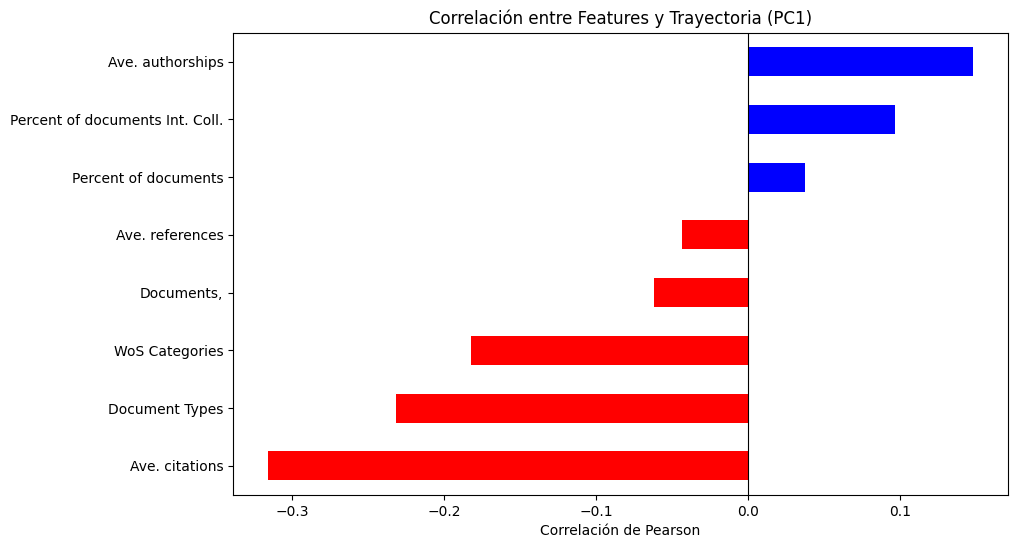

In [35]:
nombres_features = [f[1] for f in global_cfg.FEATURES]
df_features = eanalysis.obtener_promedios_anuales(df_flujo['year'].values, nombres_features, global_cfg.DATA_FOLDER)
df_flujo, correlaciones = eanalysis.correlacionar_y_alinear(df_flujo, df_features, ecfg.ALIGN_PC1_ANCHOR)

eviz.plot_correlaciones_barras(correlaciones)

In [36]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        4.153846        1.538462    5.500000       25.557692   
1981        3.444444        1.428571    4.904762       26.207778   
1982        4.465517        1.465517    6.172414       87.475690   
1983        3.657143        1.371429    4.885714       48.827143   
1984        3.422222        1.466667    5.133333       38.730889   
1985        3.696970        1.454545    6.242424       29.730303   
1986        4.388889        1.388889   11.000000       24.320000   
1987        5.363636        1.835664    8.052448       40.816503   
1988        4.476562        1.625000    4.570312       39.999922   
1989        3.098361        1.327869    4.114754       20.946885   
1990        4.190476        1.523810    4.464286       42.731905   
1991        5.323770        1.803279    8.204918       26.269180   
1992        5.111607        1.691964    7.049107       30.247589   
1993        3.805825        1.533981    5.456311

In [37]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
#"Ave. authorships"
# 5. Gráficas de Comparación
df_plot, df_comparacion = eanalysis.preparar_datos_comparacion(df_features, df_flujo)
eviz.plot_feature_individual(df_plot, "Ave. authorships")
eviz.plot_comparacion_normalizada(df_comparacion)

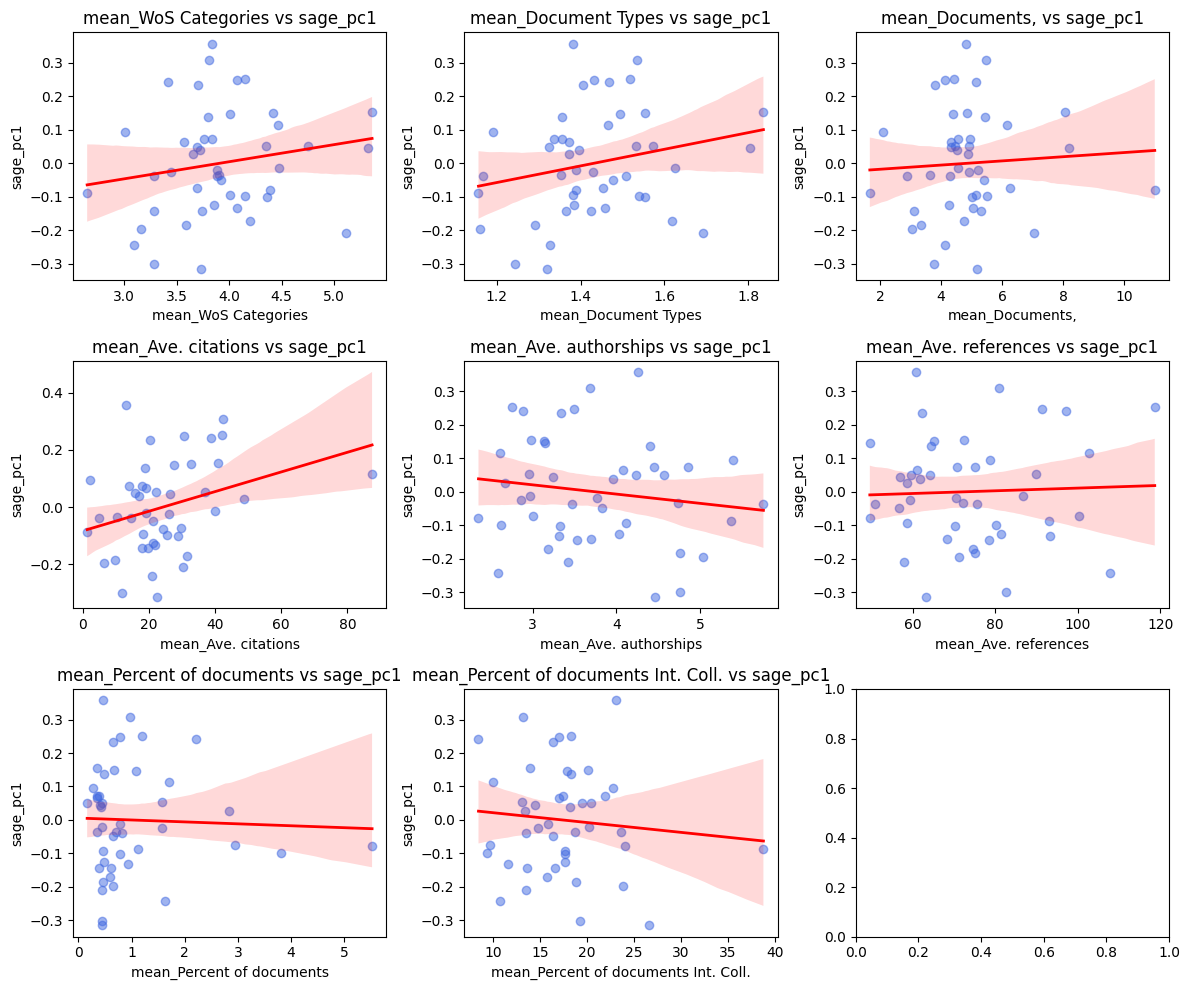

In [38]:
df_all = stat_analysis.cargar_y_unir_datos(cfg.LEVEL) #cargamos y preparamos los datos
#Exploración visual inicial
stat_viz.plot_dispersion_ols(df_all, 'mean_Percent of documents', 'sage_pc1')
# Los candidatos son exactamente los features definidos para hacer el embedding de sage
features_candidatas = [f"mean_{tupla[1]}" for tupla in global_cfg.FEATURES] # Extraemos el segundo elemento de la tupla (tupla[1]) y le pegamos "mean_"
stat_viz.plot_matriz_features(df_all, features_candidatas)

In [39]:
# Modelos OLS
# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. citations', "mean_Ave. authorships"])
print(modelo_mult.summary())


#y = df_all['sage_pc1']  #variable objetivo
#X = df_all[['mean_Percent of documents', 'mean_Ave. authorships']] #Variables predictoras

# Le ponemos su constante 
#Ecuacion lineal de la forma y=b0 + b1x1 + b2x2 donde los xn son los atributos
#X = sm.add_constant(X) #cada atributo definido en X es un valor asociado a x_n, b0 es la constante (lo definimos como 1), b1 y b2 son los valores a estimar
#modelo = sm.OLS(y, X).fit()
#print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     1.880
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.148
Time:                        23:18:49   Log-Likelihood:                 22.106
No. Observations:                  45   AIC:                            -36.21
Df Residuals:                      41   BIC:                            -28.98
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [40]:

# Múltiple sin HAC

modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships', 'mean_WoS Categories',
                                                                    'mean_Document Types', 'mean_Documents,','mean_Ave. citations',
                                                                    'mean_Ave. references','mean_Percent of documents Int. Coll.'])
print(modelo_mult.summary())


                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                 -0.024
Method:                 Least Squares   F-statistic:                    0.8701
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.550
Time:                        23:18:49   Log-Likelihood:                 23.184
No. Observations:                  45   AIC:                            -28.37
Df Residuals:                      36   BIC:                            -12.11
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [41]:
# Simple con HAC
modelo_simple = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Ave. authorships'], usar_hac=True, maxlags=3)
print(modelo_simple.summary())
#mean_Percent of documents

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     2.133
Date:                Wed, 18 Mar 2026   Prob (F-statistic):              0.151
Time:                        23:18:49   Log-Likelihood:                 19.707
No. Observations:                  45   AIC:                            -35.41
Df Residuals:                      43   BIC:                            -31.80
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.10

------------------------------------------------------------
Diagnostico de residuos
------------------------------------------------------------
Prueba de Durbin-Watson (Independencia): 2.178
Prueba de Shapiro-Wilk (Normalidad): p-value = 0.8526
Prueba de Breusch-Pagan (Homocedasticidad): p-value = 0.3822


/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.



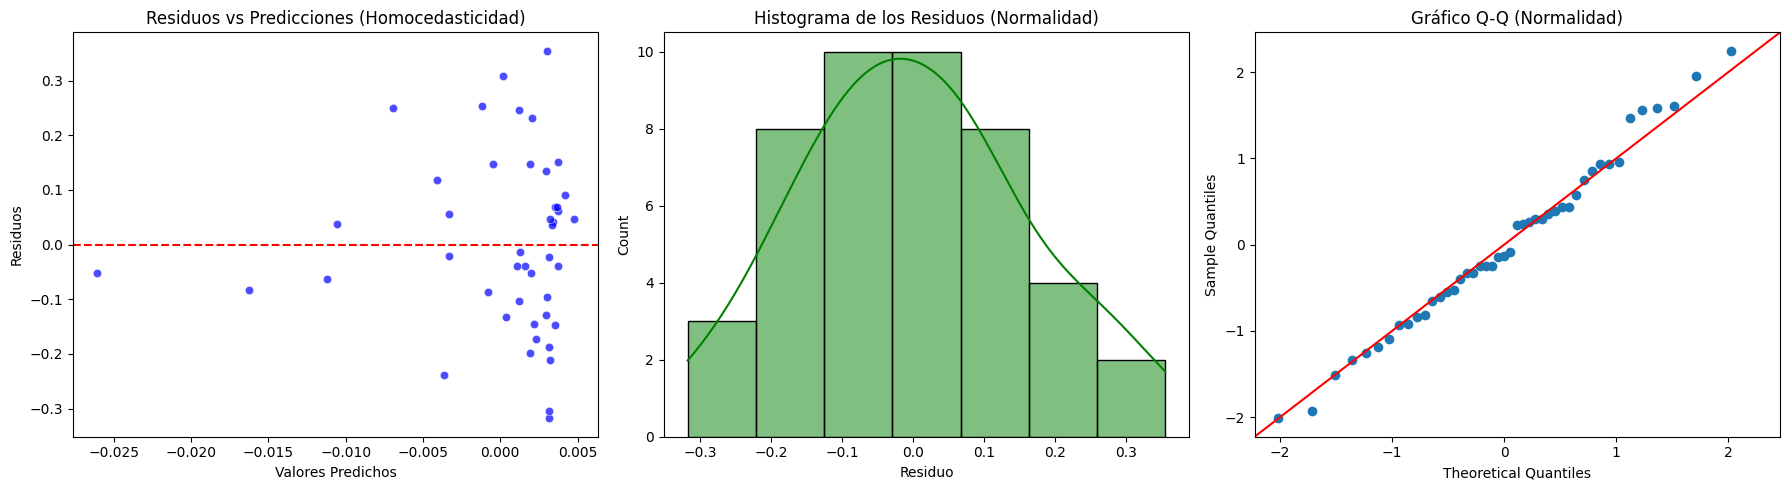

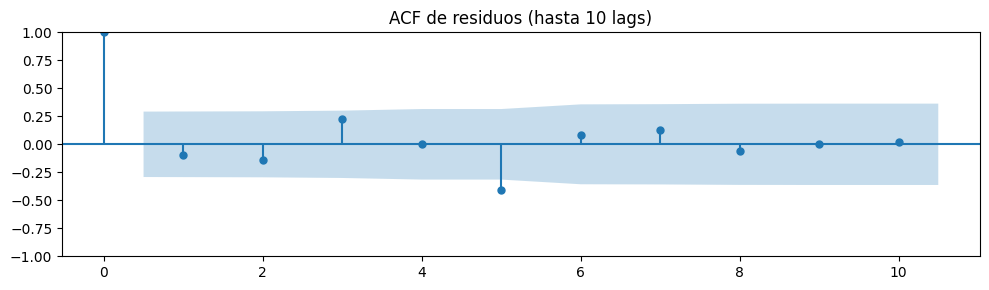

In [42]:
# Diagnóstico de residuos (del modelo simple normal para ver los errores puros)
modelo_base = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'])
residuos, predicciones = stat_analysis.ejecutar_diagnostico_residuos(modelo_base)

stat_viz.plot_panel_residuos(predicciones, residuos)
stat_viz.plot_acf_residuos(df_all, residuos)

In [43]:
modelo_multiple = stat_analysis.ajustar_modelo_ols(
    df_all, 
    'sage_pc1', 
    ['mean_Percent of documents', 'mean_Ave. authorships'], 
    usar_hac=True, 
    maxlags=3
)
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                     2.482
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0958
Time:                        23:18:50   Log-Likelihood:                 20.214
No. Observations:                  45   AIC:                            -34.43
Df Residuals:                      42   BIC:                            -29.01
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 